In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/supplement"
st.utils.setup_plotting(figure_dir, display_dpi=200)

import pandas as pd
import scanpy as sc

## Load data

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.2-kidney_tcr_clonal_clusters_peri_glom_annot.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [3]:
adata.obs["region"] = "Tubulointerstitial"
adata.obs.loc[adata.obs["in_glom"], "region"] = "Glomerular"
adata.obs.loc[adata.obs["in_peri_glom"], "region"] = "Periglomerular"
adata = adata[adata.obs["region"] != "Glomerular"]

adata.obs["sample_short"] = (
    adata.obs["sample"]
    .astype(str)
    .map({sample: f"S{i}" for i, sample in enumerate(adata.obs["sample"].unique())})
)

ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

/tmp/ipykernel_95365/1457555519.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample_short"] = (


In [4]:
ct_key = "cell_type_l1.1"
df = (
    ad_t.obs.groupby(ct_key, observed=True)["region"]
    .value_counts(normalize=True)
    .unstack()
)
df

region,Periglomerular,Tubulointerstitial
cell_type_l1.1,,
CD4+,0.238633,0.761367
CD8+,0.221925,0.778075
MAIT,0.230866,0.769134
NKT-like,0.160127,0.839873
gdT,0.200924,0.799076


0.014189858101418986 0.013340807564088715


/tmp/ipykernel_95365/753271194.py:150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


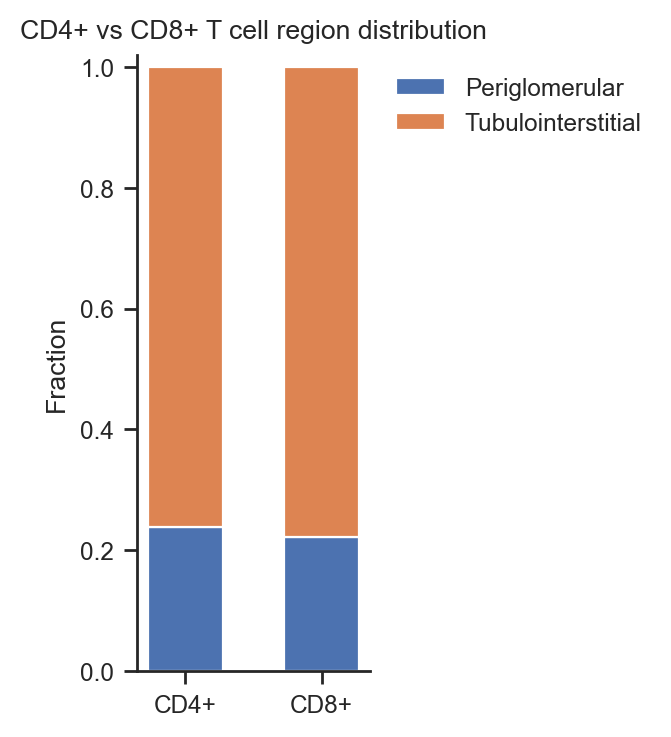

({'method': 'chi2',
  'chi2': 6.1233456282436425,
  'dof': 1,
  'p': 0.013340807564088715,
  'expected': array([[2364.65866199, 7818.34133801],
         [1474.34133801, 4874.65866199]])},
 {'method': 'mc_exact_2xk',
  'chi2': 6.1233456282436425,
  'p': 0.014189858101418986,
  'n_mc': 100000,
  'seed': 0})

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency, hypergeom


def region_counts(
    ad_t,
    ct_key: str,
    region_key: str = "region",
    ct_values: tuple[str, str] = ("CD4+", "CD8+"),
) -> pd.DataFrame:
    """Return 2xK integer contingency table: rows=ct_values, cols=regions."""
    counts = (
        ad_t.obs.groupby(ct_key, observed=True)[region_key]
        .value_counts()
        .unstack(fill_value=0)
        .astype(int)
    )
    missing = [c for c in ct_values if c not in counts.index]
    if missing:
        raise ValueError(f"Missing cell types in data: {missing}")
    return counts.loc[list(ct_values)]


def chi2_homogeneity_test(table_2xk: pd.DataFrame) -> dict:
    """Chi-square test of homogeneity (global test of equal distributions)."""
    chi2, p, dof, expected = chi2_contingency(table_2xk.values, correction=False)
    return {
        "method": "chi2",
        "chi2": float(chi2),
        "dof": int(dof),
        "p": float(p),
        "expected": expected,
    }


def _rvs_multivariate_hypergeom_sequential(
    col_totals: np.ndarray, n_draw: int, rng: np.random.Generator
) -> np.ndarray:
    K = len(col_totals)
    remaining_pop = int(col_totals.sum())
    remaining_draw = int(n_draw)
    out = np.zeros(K, dtype=int)

    for j in range(K - 1):
        Nj = int(col_totals[j])
        if remaining_draw == 0 or Nj == 0:
            xj = 0
        else:
            # hypergeom: population=remaining_pop, success=Nj, draws=remaining_draw
            xj = int(
                hypergeom.rvs(M=remaining_pop, n=Nj, N=remaining_draw, random_state=rng)
            )
        out[j] = xj
        remaining_pop -= Nj
        remaining_draw -= xj

    out[-1] = remaining_draw
    return out


def exact_2xk_mc_pvalue(
    table_2xk: pd.DataFrame, n_mc: int = 100_000, seed: int = 0
) -> dict:
    obs = table_2xk.values.astype(int)
    if obs.shape[0] != 2:
        raise ValueError("exact_2xk_mc_pvalue expects a 2xK table.")

    rng = np.random.default_rng(seed)
    row_sums = obs.sum(axis=1)
    col_totals = obs.sum(axis=0)

    # observed chi2 under independence (same as homogeneity)
    chi2_obs, _, _, _ = chi2_contingency(obs, correction=False)

    ge = 0
    for _ in range(n_mc):
        row1 = _rvs_multivariate_hypergeom_sequential(col_totals, int(row_sums[0]), rng)
        sim = np.vstack([row1, col_totals - row1])
        chi2_sim, _, _, _ = chi2_contingency(sim, correction=False)
        ge += chi2_sim >= chi2_obs

    # +1 smoothing for stability
    p_mc = (ge + 1) / (n_mc + 1)
    return {
        "method": "mc_exact_2xk",
        "chi2": float(chi2_obs),
        "p": float(p_mc),
        "n_mc": int(n_mc),
        "seed": int(seed),
    }


def _p_to_stars(p: float) -> str:
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def plot_stacked_side_by_side(
    table_2xk: pd.DataFrame,
    p_value: float | None = None,
    title: str | None = None,
    show_ns: bool = True,
    figsize: tuple[float, float] = (2, 3.8),
):
    counts = table_2xk.copy()
    fracs = counts.div(counts.sum(axis=1), axis=0)

    celltypes = list(fracs.index)  # ["CD4+","CD8+"]
    regions = list(fracs.columns)  # K regions

    x = np.array([0.0, 1.0])
    width = 0.55

    fig, ax = plt.subplots(figsize=figsize)

    bottoms = np.zeros(2)
    for r in regions:
        vals = fracs[r].values
        ax.bar(x, vals, width=width, bottom=bottoms, label=r)
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(celltypes)
    ax.set_ylabel("Fraction")
    ax.set_ylim(0, 1.02)
    if title:
        ax.set_title(title)

    # significance bracket
    if p_value is not None:
        stars = _p_to_stars(p_value)
        if stars != "ns" or show_ns:
            y = 1.04
            h = 0.03
            ax.plot([x[0], x[0], x[1], x[1]], [y, y + h, y + h, y], lw=1.2)
            # Stars above the bracket
            ax.text(x.mean(), y + h, stars, ha="center", va="bottom")
            # P-value below the bracket
            ax.text(x.mean(), y + 0.01, f"p={p_value:.2g}", ha="center", va="top")

    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    return fig, ax


# -------------------- Usage with your objects --------------------
# (your region assignment + subset)
# adata.obs["region"] = "Tubulointerstitial"
# adata.obs.loc[adata.obs["in_glom"], "region"] = "Glomerular"
# adata.obs.loc[adata.obs["in_peri_glom"], "region"] = "Periglomerular"
# ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

ct_key = "cell_type_l1.1"
tab = region_counts(
    ad_t, ct_key=ct_key, region_key="region", ct_values=("CD4+", "CD8+")
)

chi2_res = chi2_homogeneity_test(tab)
# If small expected counts, also compute MC-exact:
mc_res = exact_2xk_mc_pvalue(tab, n_mc=100_000, seed=0)

# choose which p to annotate (often: mc_res if sparse)
p_annotate = mc_res["p"] if (chi2_res["expected"] < 5).any() else chi2_res["p"]
print(mc_res["p"], chi2_res["p"])
fig, ax = plot_stacked_side_by_side(
    tab,
    # p_value=p_annotate,
    title="CD4+ vs CD8+ T cell region distribution",
    figsize=(1.5, 4),
)
plt.show()

chi2_res, mc_res

/tmp/ipykernel_95365/2009737720.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.92))


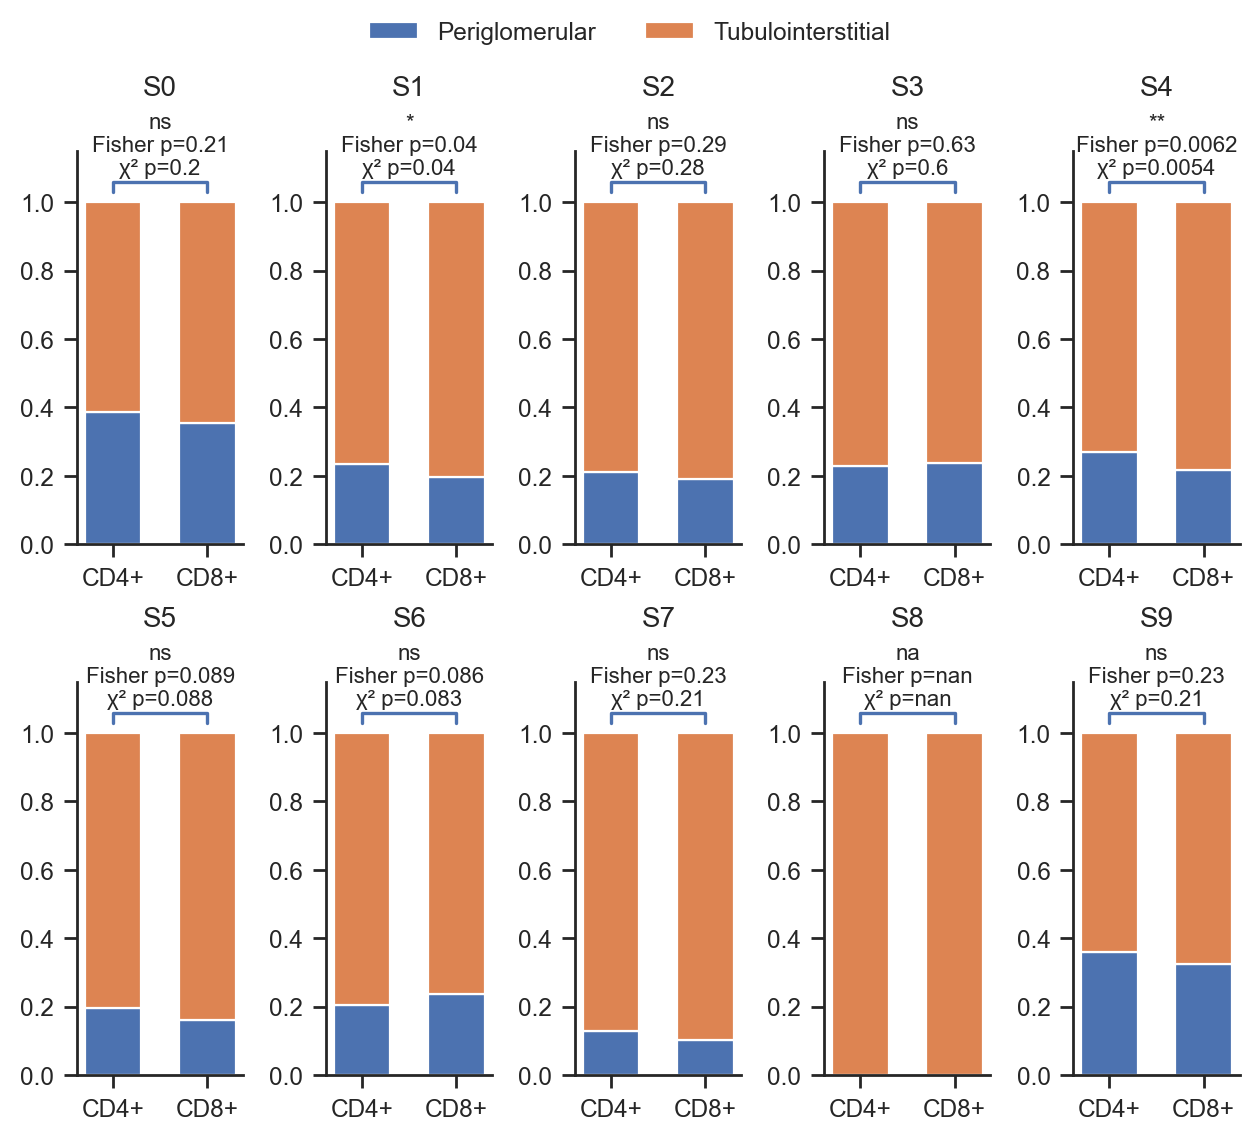

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import gammaln


def _p_to_stars(p: float) -> str:
    if not np.isfinite(p):
        return "na"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def _mvhypergeom_logpmf(x: np.ndarray, N: np.ndarray) -> float:
    x = np.asarray(x, dtype=int)
    N = np.asarray(N, dtype=int)
    if np.any(x < 0) or np.any(x > N):
        return -np.inf

    n = int(x.sum())
    M = int(N.sum())

    def logC(a, b):
        return gammaln(a + 1) - gammaln(b + 1) - gammaln(a - b + 1)

    num = np.sum([logC(int(Nj), int(xj)) for Nj, xj in zip(N, x)])
    den = logC(M, n)
    return float(num - den)


def _enumerate_row1_vectors(col_totals: np.ndarray, row1_sum: int):
    col_totals = np.asarray(col_totals, dtype=int)
    K = len(col_totals)
    x = np.zeros(K, dtype=int)

    def rec(j, remaining_draw, remaining_cols_total):
        if j == K - 1:
            xj = remaining_draw
            if 0 <= xj <= col_totals[j]:
                x[j] = xj
                yield x.copy()
            return

        Nj = int(col_totals[j])
        remaining_after = int(remaining_cols_total - Nj)

        lo = max(0, remaining_draw - remaining_after)
        hi = min(Nj, remaining_draw)

        for xj in range(lo, hi + 1):
            x[j] = xj
            yield from rec(j + 1, remaining_draw - xj, remaining_cols_total - Nj)

    yield from rec(0, int(row1_sum), int(col_totals.sum()))


def fisher_2xk_exact(table_2xk: np.ndarray) -> dict:
    """
    Exact conditional p-value for a 2xK table (Fisher–Freeman–Halton style),
    using Pearson chi-square as the extremeness statistic.
    """
    obs = np.asarray(table_2xk, dtype=int)
    if obs.shape[0] != 2:
        raise ValueError("Expected a 2xK table.")

    col_sums = obs.sum(axis=0)
    keep = col_sums > 0
    obs = obs[:, keep]
    col_sums = col_sums[keep]

    if obs.shape[1] < 2:
        return {
            "p": np.nan,
            "chi2_obs": np.nan,
            "n_tables": 0,
            "note": "Need >=2 non-empty regions",
        }

    row_sums = obs.sum(axis=1)
    if np.any(row_sums == 0):
        return {
            "p": np.nan,
            "chi2_obs": np.nan,
            "n_tables": 0,
            "note": "One row has zero count",
        }

    chi2_obs, _, _, _ = chi2_contingency(obs, correction=False)

    logps, chi2s = [], []
    n_tables = 0

    for x in _enumerate_row1_vectors(col_sums, int(row_sums[0])):
        sim = np.vstack([x, col_sums - x])
        chi2_sim, _, _, _ = chi2_contingency(sim, correction=False)
        logp = _mvhypergeom_logpmf(x, col_sums)
        if np.isfinite(logp):
            n_tables += 1
            logps.append(logp)
            chi2s.append(float(chi2_sim))

    logps = np.array(logps, dtype=float)
    chi2s = np.array(chi2s, dtype=float)

    m = logps.max()
    ps = np.exp(logps - m)
    ps = ps / ps.sum()

    p_exact = float(ps[chi2s >= float(chi2_obs) - 1e-12].sum())
    return {
        "p": p_exact,
        "chi2_obs": float(chi2_obs),
        "n_tables": int(n_tables),
        "note": "",
    }


def fisher_2xk_mc(table_2xk: np.ndarray, n_mc: int = 50_000, seed: int = 0) -> dict:
    """
    Conditional Monte Carlo (Fisher-style) p-value for 2xK, conditioning on margins.
    """
    obs = np.asarray(table_2xk, dtype=int)
    col_sums = obs.sum(axis=0)
    keep = col_sums > 0
    obs = obs[:, keep]
    col_sums = col_sums[keep]

    if obs.shape[1] < 2:
        return {
            "p": np.nan,
            "chi2_obs": np.nan,
            "n_mc": 0,
            "note": "Need >=2 non-empty regions",
        }

    row_sums = obs.sum(axis=1)
    if np.any(row_sums == 0):
        return {
            "p": np.nan,
            "chi2_obs": np.nan,
            "n_mc": 0,
            "note": "One row has zero count",
        }

    chi2_obs, _, _, _ = chi2_contingency(obs, correction=False)

    rng = np.random.default_rng(seed)
    K = len(col_sums)

    def rvs_row1():
        # sequential hypergeometric construction
        out = np.zeros(K, dtype=int)
        remaining_pop = int(col_sums.sum())
        remaining_draw = int(row_sums[0])

        for j in range(K - 1):
            Nj = int(col_sums[j])
            if remaining_draw == 0 or Nj == 0:
                xj = 0
            else:
                xj = int(
                    hypergeom.rvs(
                        M=remaining_pop, n=Nj, N=remaining_draw, random_state=rng
                    )
                )
            out[j] = xj
            remaining_pop -= Nj
            remaining_draw -= xj
        out[-1] = remaining_draw
        return out

    ge = 0
    for _ in range(n_mc):
        row1 = rvs_row1()
        sim = np.vstack([row1, col_sums - row1])
        chi2_sim, _, _, _ = chi2_contingency(sim, correction=False)
        ge += chi2_sim >= chi2_obs

    p_mc = (ge + 1) / (n_mc + 1)
    return {
        "p": float(p_mc),
        "chi2_obs": float(chi2_obs),
        "n_mc": int(n_mc),
        "note": "",
    }


def contingency_tables_per_sample(
    ad_t,
    sample_key: str,
    ct_key: str,
    region_key: str,
    ct_values: tuple[str, str] = ("CD4+", "CD8+"),
) -> dict[str, pd.DataFrame]:
    obs = ad_t.obs[[sample_key, ct_key, region_key]].copy()
    obs = obs[obs[ct_key].isin(ct_values)]

    out = {}
    for s, g in obs.groupby(sample_key, observed=True):
        tab = (
            g.groupby(ct_key, observed=True)[region_key]
            .value_counts()
            .unstack(fill_value=0)
            .astype(int)
        )
        for ct in ct_values:
            if ct not in tab.index:
                tab.loc[ct] = 0
        tab = tab.loc[list(ct_values)]
        tab = tab.loc[:, tab.sum(axis=0) > 0]  # drop empty regions for that sample
        out[str(s)] = tab
    return out


def plot_per_sample_stacked_bars(
    ad_t,
    sample_key: str = "sample",
    ct_key: str = "cell_type_l1.1",
    region_key: str = "region",
    ct_values: tuple[str, str] = ("CD4+", "CD8+"),
    annotate_with: str = "fisher",  # "fisher" | "chi2"
    fisher_exact_max_tables: int = 300_000,
    fisher_mc_n: int = 50_000,
    seed: int = 0,
    ncols: int = 5,
):
    tables = contingency_tables_per_sample(
        ad_t, sample_key, ct_key, region_key, ct_values
    )
    all_regions = sorted({r for tab in tables.values() for r in tab.columns})

    n = len(tables)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(1.5 * ncols, 3 * nrows),
        squeeze=False,
        gridspec_kw={"wspace": 0.5, "hspace": 0.35},
    )

    handles_labels = None

    for idx, (s, tab) in enumerate(sorted(tables.items(), key=lambda x: x[0])):
        ax = axes[idx // ncols][idx % ncols]

        # plotting table (optionally aligned to global regions)
        tab_plot = tab.reindex(columns=all_regions, fill_value=0).astype(int)
        arr_plot = tab_plot.values

        # stats table: DROP empty columns (critical for chi2_contingency)
        tab_stats = tab.loc[:, tab.sum(axis=0) > 0].astype(int)
        arr_stats = tab_stats.values

        # fractions for plotting
        row_sums = arr_plot.sum(axis=1, keepdims=True)
        fracs = np.divide(
            arr_plot,
            row_sums,
            out=np.zeros_like(arr_plot, dtype=float),
            where=row_sums > 0,
        )

        # chi-square (only if at least 2 non-empty regions and both rows >0)
        if (arr_stats.shape[1] >= 2) and np.all(arr_stats.sum(axis=1) > 0):
            chi2, p_chi2, dof, expected = chi2_contingency(arr_stats, correction=False)
            _ = float(np.min(expected))
        else:
            p_chi2, _ = np.nan, np.nan

        # Fisher-style exact (your helper already drops empty cols internally, but pass stats table anyway)
        arr_for_fisher = arr_stats
        try:
            tmp = fisher_2xk_exact(arr_for_fisher)
            if tmp["n_tables"] > fisher_exact_max_tables:
                fisher_res = fisher_2xk_mc(arr_for_fisher, n_mc=fisher_mc_n, seed=seed)
                fisher_label = f"Fisher(MC) p={fisher_res['p']:.2g}"
            else:
                fisher_res = tmp
                fisher_label = f"Fisher p={fisher_res['p']:.2g}"
        except Exception:
            fisher_res = fisher_2xk_mc(arr_for_fisher, n_mc=fisher_mc_n, seed=seed)
            fisher_label = f"Fisher(MC) p={fisher_res['p']:.2g}"

        # annotation choice
        p_anno = fisher_res["p"] if annotate_with == "fisher" else p_chi2
        stars = _p_to_stars(p_anno)

        # plot two stacked bars (CD4, CD8) with stacks=regions
        x = np.array([0.0, 1.0])
        width = 0.6
        bottoms = np.zeros(2)

        for j, region in enumerate(all_regions):
            vals = fracs[:, j]
            ax.bar(x, vals, width=width, bottom=bottoms, label=region)
            bottoms += vals

        if handles_labels is None:
            handles_labels = ax.get_legend_handles_labels()

        ax.set_xticks(x)
        ax.set_xticklabels(list(ct_values))
        ax.set_ylim(0, 1.15)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(str(s), fontsize=10, pad=20)

        # bracket + text
        y = 1.03
        h = 0.03
        ax.plot([x[0], x[0], x[1], x[1]], [y, y + h, y + h, y], lw=1.2)

        if annotate_with == "fisher":
            txt = f"{stars}\n{fisher_label}\nχ² p={p_chi2:.2g}"
        else:
            txt = f"{stars}\nχ² p={p_chi2:.2g}\n{fisher_label}"
        ax.text(x.mean(), y + h + 0.01, txt, ha="center", va="bottom", fontsize=8)

    # hide unused axes
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    if handles_labels is not None:
        handles, labels = handles_labels
        fig.legend(
            handles, labels, loc="upper center", ncol=min(len(labels), 6), frameon=False
        )

    fig.tight_layout(rect=(0, 0, 1, 0.92))
    return fig


# ---- Usage with your preprocessing ----
# adata.obs["region"] = "Tubulointerstitial"
# adata.obs.loc[adata.obs["in_glom"], "region"] = "Glomerular"
# adata.obs.loc[adata.obs["in_peri_glom"], "region"] = "Periglomerular"
# ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

fig = plot_per_sample_stacked_bars(
    ad_t,
    sample_key="sample_short",
    ct_key="cell_type_l1.1",
    region_key="region",
    ct_values=("CD4+", "CD8+"),
    annotate_with="fisher",  # or "chi2"
    fisher_exact_max_tables=300_000,  # set to e.g. 10_000_000 if you truly want to force exact more often
    fisher_mc_n=50_000,
    seed=0,
)
plt.show()